# INSTALLASI PACKAGE

In [20]:
pip install ucimlrepo

#PEMANGGILAN LIBRARY

In [21]:
import ucimlrepo

#MELIHAT DATASET YANG DISEDIAKAN

In [13]:
dir(ucimlrepo)

['API_BASE_URL',
 'API_LIST_URL',
 'DATASET_FILE_BASE_URL',
 'DatasetNotFoundError',
 'Optional',
 'VALID_FILTERS',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'certifi',
 'dotdict',
 'fetch',
 'fetch_ucirepo',
 'json',
 'list_available_datasets',
 'pd',
 'ssl',
 'urllib']

In [4]:
from ucimlrepo import list_available_datasets

In [6]:
data = list_available_datasets()

-------------------------------------
The following datasets are available:
-------------------------------------
Dataset Name                                                                            ID    
------------                                                                            --    
Abalone                                                                                 1     
Adult                                                                                   2     
Annealing                                                                               3     
Audiology (Standardized)                                                                8     
Auto MPG                                                                                9     
Automobile                                                                              10    
Balance Scale                                                                           12    
Balloons                       

In [35]:
datasets = fetch_ucirepo(id=155)

In [36]:
datasets

{'data': {'ids': None,
  'features':       visible-mean  visible-max  visible-min  mean-distribution  contrast  \
  0           3.0000     140.0000      43.5000             0.0833  862.8417   
  1           3.0000     135.0000      41.9063             0.0790  690.3291   
  2           2.0000     126.0000      21.0586             0.0406  308.3583   
  3           4.0000     197.0000      77.4805             0.0890  874.4709   
  4           7.0000     193.0000      88.8398             0.0884  810.1126   
  ...            ...          ...          ...                ...       ...   
  2043        6.0048      57.3856      23.0036             5.1917   48.4833   
  2044        5.3599      48.1413      13.9600             1.5125    9.3375   
  2045        7.9397      48.7863      20.7169             1.7500    7.8167   
  2046        6.6498      61.2553      23.0195             4.6750   49.2167   
  2047        4.9299      31.5877      14.6402             1.7875    7.3292   
  
        entrop

#IMPORT LIBRARY

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score

#LOAD DATA

In [44]:
url = 'https://archive.ics.uci.edu/static/public/155/data.csv'
df = pd.read_csv(url)

In [45]:
df

,visible-mean,visible-max,visible-min,mean-distribution,contrast,entropy,second-angular-momentum,ir-mean,ir-max,ir-min
0,3.0000,140.0000,43.5000,0.0833,862.8417,0.0254,3.8890,163.0000,240.0000,213.3555
1,3.0000,135.0000,41.9063,0.0790,690.3291,0.0259,3.8340,167.0000,239.0000,213.7188
2,2.0000,126.0000,21.0586,0.0406,308.3583,0.0684,3.1702,174.0000,240.0000,227.5859
3,4.0000,197.0000,77.4805,0.0890,874.4709,0.0243,3.9442,155.0000,239.0000,197.2773
4,7.0000,193.0000,88.8398,0.0884,810.1126,0.0223,3.9318,150.0000,236.0000,186.0195
...,...,...,...,...,...,...,...,...,...,...
2043,6.0048,57.3856,23.0036,5.1917,48.4833,0.0828,2.6890,-24.0380,33.7879,19.0423
2044,5.3599,48.1413,13.9600,1.5125,9.3375,0.3567,1.5600,-78.0507,35.0668,14.7995
2045,7.9397,48.7863,20.7169,1.7500,7.8167,0.2291,1.7824,-79.7594,30.7739,-11.1662
2046,6.6498,61.2553,23.0195,4.6750,49.2167,0.1089,2.5540,-71.8420,29.9047,0.7110


#MEMILIH FITUR NUMERIK

In [48]:
features = df.select_dtypes(include=[np.number])

#STANDARISASI DATA

In [69]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# PCA (Principal Component Analysis)

In [72]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
df['PCA1'], df['PCA2'] = pca_data[:, 0], pca_data[:, 1]


#KMeans Clustering

In [80]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['KMeans'] = kmeans.fit_predict(scaled_data)

#Agglomerative Clustering

In [81]:
agglo = AgglomerativeClustering(n_clusters=4)
df['Agglo'] = agglo.fit_predict(scaled_data)

#Isolation Forest (Anomaly Detection)

In [82]:
iso = IsolationForest(contamination=0.05, random_state=42)
df['Anomaly'] = iso.fit_predict(scaled_data)


#Visualisasi Hasil Clustering

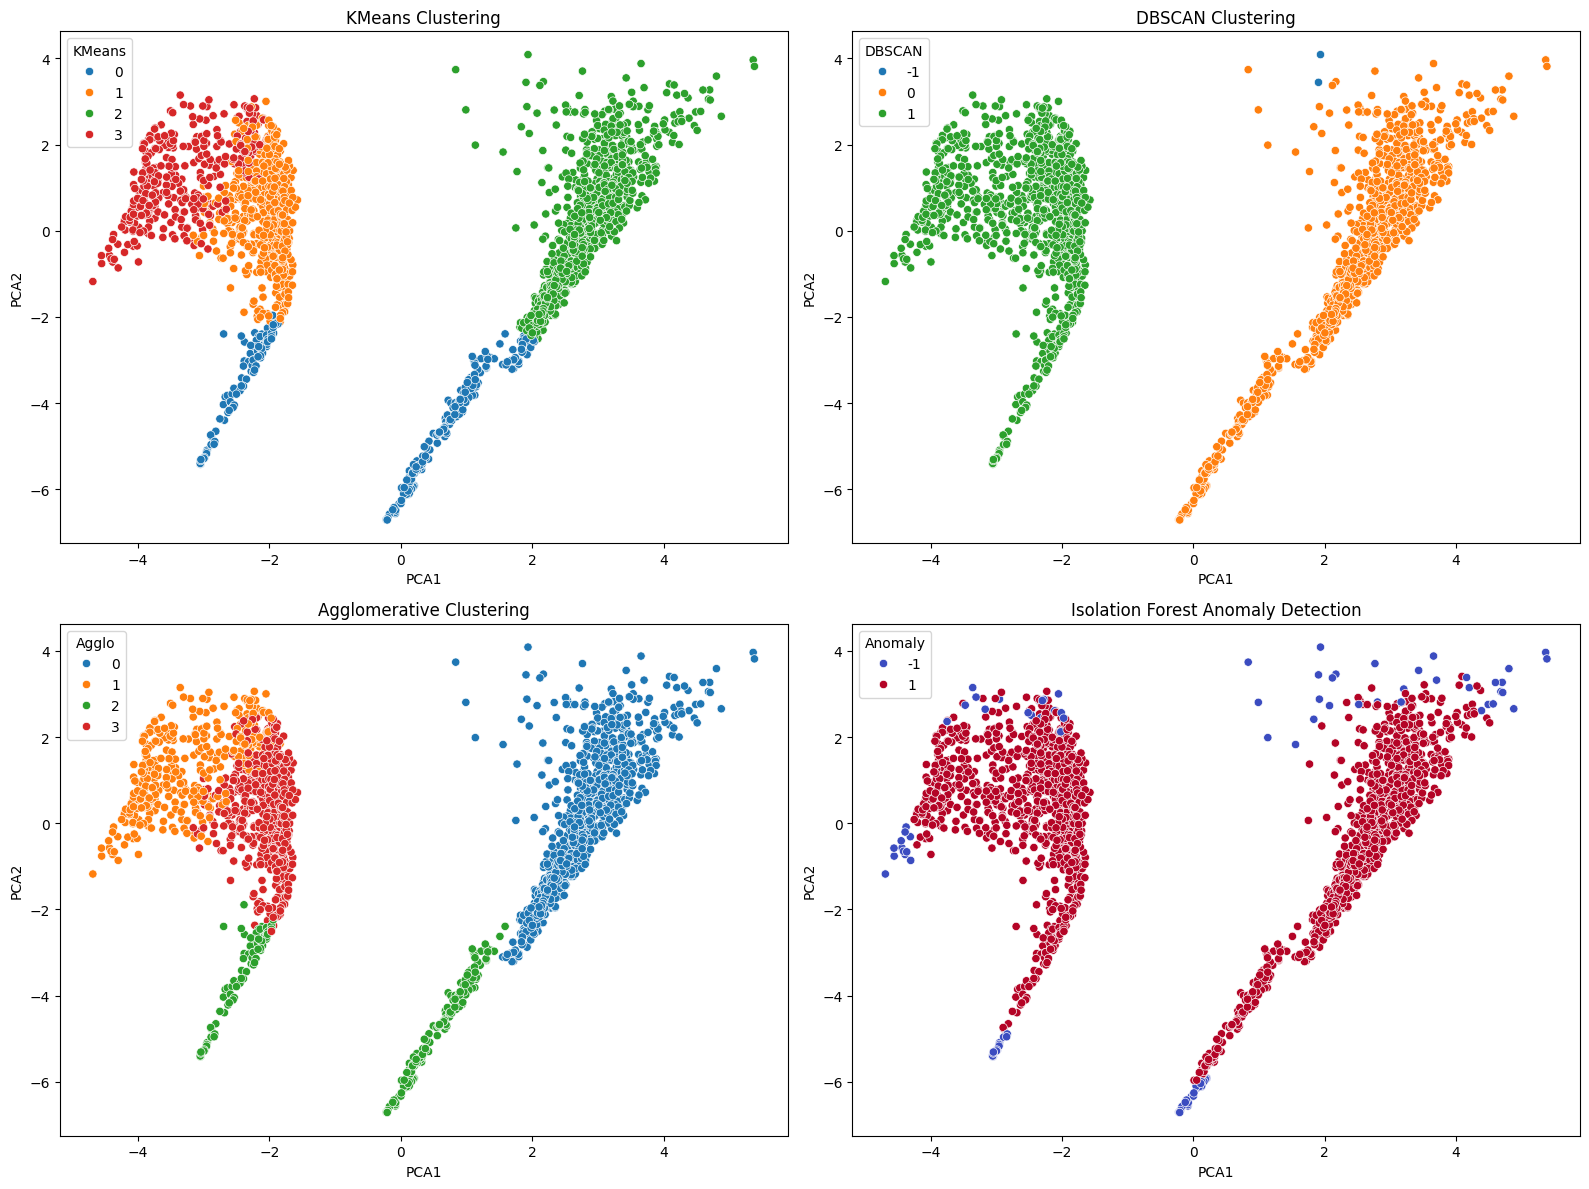

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='KMeans', palette='tab10', ax=axes[0, 0]).set_title('KMeans Clustering')
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='DBSCAN', palette='tab10', ax=axes[0, 1]).set_title('DBSCAN Clustering')
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Agglo', palette='tab10', ax=axes[1, 0]).set_title('Agglomerative Clustering')
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Anomaly', palette='coolwarm', ax=axes[1, 1]).set_title('Isolation Forest Anomaly Detection')
plt.tight_layout()
plt.show()